
# Special Case: Tree Pruning for Explainability

📚 This tutorial demonstrates the three **tree pruning strategies** available in Forest-Guided Clustering for proximity-based distance metrics.

Standard Random Forest proximity measures similarity between two samples based on how frequently they end up in the **same terminal leaf** across the forest. While this works well for many classification tasks, very deep forests, especially for regression tasks, often produce extremely fine-grained terminal nodes. In such settings, many samples end up in unique leaves, resulting in sparse proximity matrices.

Tree pruning alleviates this problem by replacing terminal leaves with **coarser inner nodes** before computing proximities. FGC currently supports three complementary strategies:

- maximum tree depth: collapse leaves to inner nodes up to a specified tree depth.
- minimum node samples: collapse leaves to the nearest inner node containing at least a specified number of training samples.
- minimum node variance: regression-specific strategy that collapses leaves according to target variance.

In this notebook, we compare all three strategies and investigate how they influence clustering stability, feature importance, and interpretability.

📦 **Installation:** To get started, you need to install the `fgclustering` package. Please follow the instructions on the [official installation guide](https://forest-guided-clustering.readthedocs.io/en/latest/_getting_started/installation.html).

🚧 **Note:** For a general introduction to FGC, please refer to our [Introduction Notebook](https://forest-guided-clustering.readthedocs.io/en/latest/_tutorials/introduction_to_FGC_use_cases.html).

**Imports:**

In [6]:
from fgclustering import (
    forest_guided_clustering,
    DistanceRandomForestProximity,
    ClusteringClara,
)

## Imports for datasets
from sklearn.datasets import fetch_california_housing

## Additional imports for use-cases
from sklearn.ensemble import RandomForestRegressor
from utils.utils import * 

## 🏠 The California Housing Dataset

We again use the **California Housing dataset** (see *Use Case 3* for a more detailed introduction), as it provides an ideal setting for demonstrating the tree-pruning strategies available in Forest-Guided Clustering.

Random Forest regressors trained on continuous targets typically grow very deep trees because the target space is recursively partitioned into increasingly fine-grained regions. As a consequence, many samples end up in unique terminal leaves, often resulting in extremely sparse proximity matrices when using the standard terminal-node proximity metric. The tree-pruning strategies introduced in this tutorial are designed to alleviate this issue by replacing terminal leaves with coarser internal tree nodes before computing sample similarities.

To focus entirely on the clustering behavior and distance formulations, we train a Random Forest Regressor directly on the full dataset. Since Random Forests provide out-of-bag (OOB) estimates for internal validation, we omit an explicit train/test split here for simplicity.

In [7]:
data_housing = fetch_california_housing(as_frame=True).frame

X_housing = data_housing.loc[:, data_housing.columns != 'MedHouseVal']
y_housing = data_housing.MedHouseVal

rf_housing = RandomForestRegressor(max_samples=0.8, max_depth=20, max_features='log2', n_estimators=100, bootstrap=True, oob_score=True, random_state=42)
rf_housing.fit(X_housing, y_housing)

print(f'OOB accuracy of prediction model: {round(rf_housing.oob_score_,3)}')

OOB accuracy of prediction model: 0.819


## 🌲 Baseline: Standard Proximity-Based Forest-Guided Clustering

We begin with the standard Random Forest proximity measure, which forms the foundation of classical Forest-Guided Clustering.

In this formulation, two samples are considered similar if they frequently end up in the **same terminal leaf** across the trees of the Random Forest. The final proximity between two samples is therefore defined as the fraction of trees in which both samples share an identical terminal node. The corresponding distance is then computed as 1 - proximity.

This approach works particularly well for many classification problems, where terminal leaves often contain multiple samples belonging to similar classes. However, for deep regression forests, terminal leaves frequently become extremely fine-grained, sometimes containing only very few samples or even single observations. In such settings, many sample pairs never share the same terminal node, resulting in highly sparse proximity matrices.

We first use this standard formulation as a baseline before introducing the different tree-pruning strategies that progressively coarsen the forest representation and increase the connectivity between samples.

In [8]:
clustering_distance_metric = DistanceRandomForestProximity(memory_efficient=True, dir_distance_matrix="./")

fgc = forest_guided_clustering(
    estimator=rf_housing, 
    X=X_housing, 
    y=y_housing, 
    clustering_distance_metric=clustering_distance_metric, 
    clustering_strategy=ClusteringClara(sampling_iter=5, sub_sample_size=0.6, method="fasterpam"),
    JI_bootstrap_iter=5, 
    JI_bootstrap_sample_size=1.0, 
    JI_discart_value=0.6,
    n_jobs=4, 
)

Using range k = (2, 6) to optimize k.


Optimizing k: 100%|██████████| 5/5 [04:54<00:00, 58.99s/it]


Optimal number of clusters k = 6

Clustering Evaluation Summary:
 k    Score  Stable  Mean_JI                                                 Cluster_JI
 2 0.858536    True    0.772                                       {1: 0.979, 2: 0.566}
 3 0.843516    True    0.770                             {1: 0.395, 2: 0.949, 3: 0.966}
 4 0.852280    True    0.758                   {1: 0.675, 2: 0.944, 3: 0.835, 4: 0.577}
 5 0.819679    True    0.746         {1: 0.427, 2: 0.731, 3: 0.935, 4: 0.693, 5: 0.943}
 6 0.802721    True    0.727 {1: 0.77, 2: 0.788, 3: 0.759, 4: 0.918, 5: 0.55, 6: 0.577}


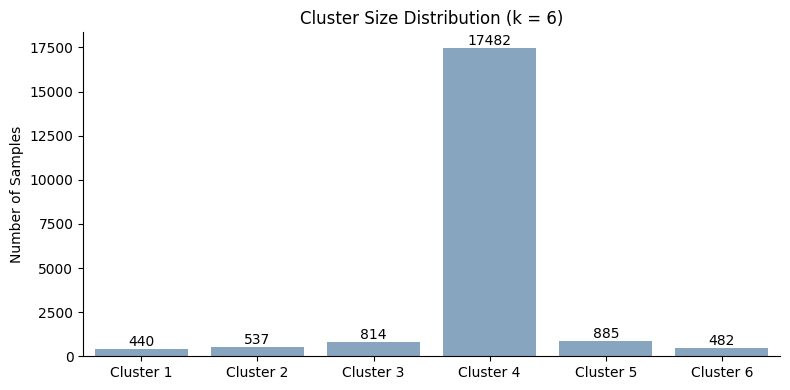

In [9]:
plot_cluster_size_distribution(fgc, fgc.best_k)

The standard proximity-based formulation produces relatively unstable and highly imbalanced clustering results on this regression dataset. Although all evaluated values of (k) pass the Jaccard stability threshold, the mean cluster stability remains comparatively moderate and several individual clusters exhibit low robustness, with some cluster-wise Jaccard scores dropping close to 0.5.

The optimizer selects k = 6 because it achieves the lowest clustering score. However, the resulting cluster distribution is highly skewed: one dominant cluster contains the vast majority of samples, while the remaining clusters are comparatively small. This indicates that the standard terminal-node proximity metric struggles to generate well-balanced cluster structures for this deep regression forest.

These results illustrate the main limitation of classical proximity-based distances in regression settings: because many samples end up in unique terminal leaves, the resulting proximity matrix becomes sparse, causing weak connectivity between samples and unstable fine-grained subgroup formation. The following tree-pruning strategies are designed to alleviate exactly this issue by coarsening the effective tree representation before computing proximities.

## ✂️ Tree-Pruning Strategies

To reduce the sparsity of the proximity matrix and obtain more robust cluster structures, Forest-Guided Clustering provides several tree-pruning strategies for the proximity-based distance metric.

Instead of computing similarities strictly from the original terminal leaves, these strategies replace terminal nodes with coarser internal tree nodes before proximities are calculated. This increases the probability that samples share the same effective node and therefore produces denser and more informative similarity structures, particularly for deep regression forests.

The pruning strategies are activated through additional parameters in `DistanceRandomForestProximity()`:

* `min_samples_in_node`
* `max_depth_for_proximity`
* `min_variance_in_node`

Each strategy controls the granularity of the effective tree representation in a different way. In the following sections, we introduce each approach individually and compare how they influence clustering stability, cluster balance, and interpretability on the California Housing dataset.

### Pruning by Maximum Tree Depth

The most straightforward pruning strategy is to restrict the effective depth of the trees using the `max_depth_for_proximity` parameter.

With this approach, terminal leaves are replaced by the nearest ancestor whose depth does not exceed the specified threshold. As a result, the forest representation becomes progressively coarser as the maximum allowed depth decreases. This prevents the proximity computation from relying on extremely fine-grained terminal regions and increases the likelihood that samples share common effective nodes.

The main advantage of this strategy is its simplicity and interpretability: the user directly controls the granularity of the effective tree structure through a single depth parameter. Smaller depth values produce broader and more general cluster structures, whereas larger values retain more detailed local information.

However, this approach applies the same pruning rule uniformly across the entire forest. In practice, some branches of a tree may justifiably require greater depth because they capture meaningful structure in the data, while other branches may overfit and become unnecessarily fine-grained. Since depth-based pruning treats all branches equally, it cannot adaptively preserve deeper structure only where it is actually informative.

In [10]:
clustering_distance_metric = DistanceRandomForestProximity(max_depth_for_proximity=10, memory_efficient=True, dir_distance_matrix="./")

fgc = forest_guided_clustering(
    estimator=rf_housing, 
    X=X_housing, 
    y=y_housing, 
    clustering_distance_metric=clustering_distance_metric, 
    clustering_strategy=ClusteringClara(sampling_iter=5, sub_sample_size=0.6, method="fasterpam"),
    JI_bootstrap_iter=5, 
    JI_bootstrap_sample_size=1.0, 
    JI_discart_value=0.6,
    n_jobs=4, 
)

Using range k = (2, 6) to optimize k.


Optimizing k: 100%|██████████| 5/5 [05:23<00:00, 64.64s/it]


Optimal number of clusters k = 6

Clustering Evaluation Summary:
 k    Score  Stable  Mean_JI                                                   Cluster_JI
 2 0.998903    True    0.684                                         {1: 0.569, 2: 0.798}
 3 0.940013    True    0.692                               {1: 0.398, 2: 0.961, 3: 0.717}
 4 0.766737   False    0.589                       {1: 0.37, 2: 0.753, 3: 0.482, 4: 0.75}
 5 0.837140    True    0.717           {1: 0.574, 2: 0.754, 3: 0.685, 4: 0.651, 5: 0.921}
 6 0.709857    True    0.788 {1: 0.904, 2: 0.952, 3: 0.962, 4: 0.884, 5: 0.667, 6: 0.359}


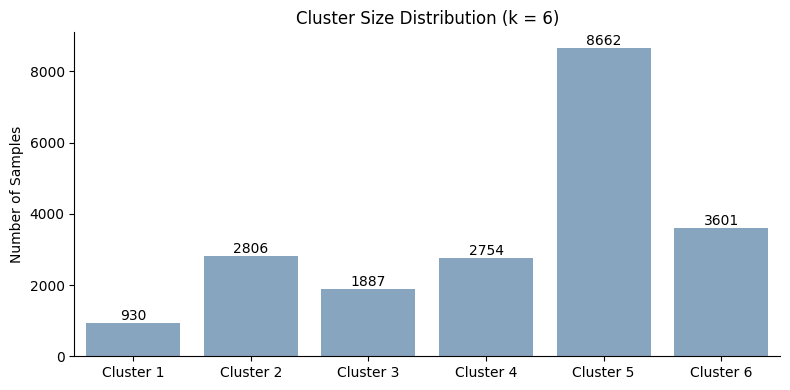

In [11]:
plot_cluster_size_distribution(fgc, fgc.best_k)

The depth-based pruning strategy produces a substantially denser and more balanced clustering structure compared to the baseline proximity formulation. While small values of (k) remain unstable, stable clustering solutions emerge from (k = 4) onward, indicating that restricting the effective tree depth successfully reduces proximity sparsity and improves sample connectivity.

The optimizer selects k = 6, which achieves the best clustering score while still maintaining acceptable stability. Compared to the baseline proximity metric, the cluster sizes become considerably more balanced, although one larger dominant cluster still remains. Importantly, several clusters now exhibit reasonably strong individual Jaccard stability values, suggesting that depth-based pruning helps recover more reproducible subgroup structure in the regression forest.

Overall, these results demonstrate that limiting the effective tree depth can substantially improve the usability of proximity-based clustering on deep regression forests by preventing the model from relying on extremely fine-grained terminal leaves.

### Pruning by Minimum Node Samples

Another pruning strategy is to require that every effective node used for proximity calculations contains at least a specified minimum number of training samples. This is controlled through the `min_samples_in_node` parameter.

With this approach, terminal leaves are collapsed upward to the nearest ancestor whose node size satisfies the specified minimum sample threshold. As a result, extremely small and highly specific terminal regions are merged into larger and more representative decision regions, increasing the probability that samples share the same effective node and thereby reducing sparsity in the proximity matrix.

Compared to depth-based pruning, this strategy allows the forest to retain **non-uniform tree depth**. Branches that continue to partition large regions of the data can still grow deeply when this structure is informative, while branches that isolate only very small subsets of samples are automatically collapsed. This makes the pruning behavior more adaptive to the local structure of the tree and allows deeper growth only where it appears justified by the data.

However, choosing an appropriate cutoff can be challenging. If the threshold is too small, the proximity matrix may remain sparse and unstable; if it is too large, the forest structure may become overly coarse and lose important local decision patterns. 

In [12]:
clustering_distance_metric = DistanceRandomForestProximity(min_samples_in_node=20, memory_efficient=True, dir_distance_matrix="./")

fgc = forest_guided_clustering(
    estimator=rf_housing, 
    X=X_housing, 
    y=y_housing, 
    clustering_distance_metric=clustering_distance_metric, 
    clustering_strategy=ClusteringClara(sampling_iter=5, sub_sample_size=0.6, method="fasterpam"),
    JI_bootstrap_iter=5, 
    JI_bootstrap_sample_size=1.0, 
    JI_discart_value=0.6,
    n_jobs=4, 
)

Using range k = (2, 6) to optimize k.


Optimizing k: 100%|██████████| 5/5 [04:59<00:00, 59.96s/it]


Optimal number of clusters k = 5

Clustering Evaluation Summary:
 k    Score  Stable  Mean_JI                                                Cluster_JI
 2 0.992640   False    0.566                                      {1: 0.203, 2: 0.929}
 3 0.974040    True    0.802                            {1: 0.706, 2: 0.737, 3: 0.963}
 4 0.848120    True    0.707                  {1: 0.385, 2: 0.907, 3: 0.599, 4: 0.936}
 5 0.796754    True    0.749          {1: 1.0, 2: 0.528, 3: 0.752, 4: 0.908, 5: 0.558}
 6 0.880335   False    0.584 {1: 0.596, 2: 0.0, 3: 0.791, 4: 0.78, 5: 0.832, 6: 0.506}


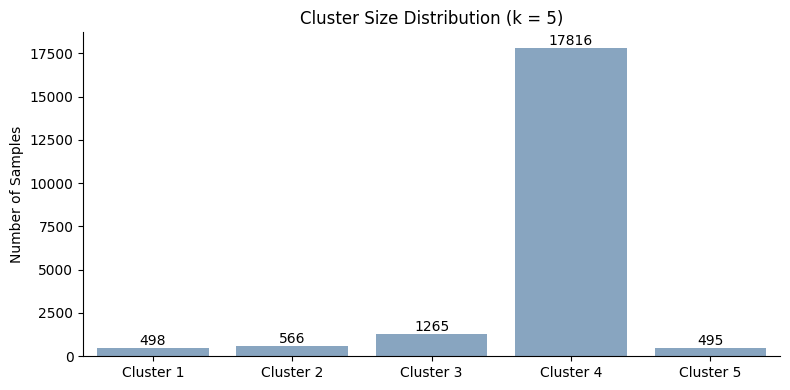

In [13]:
plot_cluster_size_distribution(fgc, fgc.best_k)

The minimum-node-sample pruning strategy improves clustering stability compared to the baseline proximity formulation, particularly for intermediate values of (k). The optimizer selects k = 5, which achieves the best clustering quality for the stable clusterings.

Compared to depth-based pruning, the clustering structure remains highly imbalanced, with one dominant cluster containing the vast majority of samples, while the remaining clusters are comparatively small. Nevertheless, several clusters exhibit strong individual Jaccard stability values, indicating that the adaptive, non-uniform pruning strategy successfully preserves some meaningful local structure in the regression forest.

Overall, these results show that minimum-node-sample pruning can stabilize proximity-based clustering while still allowing deeper tree growth where sufficient sample support exists. However, balancing sparsity reduction and preservation of fine-grained structure remains challenging, as overly aggressive pruning can still lead to dominant coarse clusters.

### Pruning by Minimum Node Variance

Both depth-based pruning and minimum-node-sample pruning impose relatively rigid structural constraints on the trees. In regression forests, however, we can exploit an additional source of information: the **target variance within each node**.

When a `RandomForestRegressor` is trained with `criterion="squared_error"`, the impurity stored in `tree_.impurity` corresponds directly to the node’s mean squared error (MSE), which is effectively the target variance within that node. For `criterion="friedman_mse"`, the impurity behaves similarly and still provides a good approximation of the local target variance, although the split selection itself additionally incorporates Friedman's improvement score.

Using the node variance as pruning criterion enables a much more adaptive and fine-grained pruning strategy. If a branch continues to grow deeper because each additional split substantially reduces the target variance, this deeper structure is likely meaningful and should be preserved. Such branches may capture important local nonlinearities or subtle substructures learned by the Random Forest model.

In contrast, once the variance within a node has already become very small, further splitting often provides only marginal additional information while greatly increasing fragmentation of the proximity matrix. In these regions, collapsing leaves back to a higher ancestor node can improve sample connectivity without sacrificing much predictive structure.

Compared to the previous pruning strategies, variance-based pruning therefore adapts directly to the *learned target structure* of the Random Forest rather than relying purely on tree topology. This often produces a more natural balance between preserving informative fine-grained regions and avoiding excessively sparse proximity matrices.

A practical limitation of this approach is that the appropriate variance threshold depends on the scale and distribution of the target variable. Selecting a suitable cutoff therefore usually requires some understanding of the underlying regression problem and may need empirical tuning.

In [14]:
clustering_distance_metric = DistanceRandomForestProximity(min_variance_in_node=0.5, memory_efficient=True, dir_distance_matrix="./")

fgc = forest_guided_clustering(
    estimator=rf_housing, 
    X=X_housing, 
    y=y_housing, 
    clustering_distance_metric=clustering_distance_metric, 
    clustering_strategy=ClusteringClara(sampling_iter=5, sub_sample_size=0.6, method="fasterpam"),
    JI_bootstrap_iter=5, 
    JI_bootstrap_sample_size=1.0, 
    JI_discart_value=0.6,
    n_jobs=4, 
)

Using range k = (2, 6) to optimize k.


Optimizing k: 100%|██████████| 5/5 [05:06<00:00, 61.22s/it]


Optimal number of clusters k = 6

Clustering Evaluation Summary:
 k    Score  Stable  Mean_JI                                                  Cluster_JI
 2 0.942788    True    0.694                                        {1: 0.763, 2: 0.624}
 3 0.898794    True    0.871                              {1: 0.968, 2: 0.823, 3: 0.821}
 4 0.530522    True    0.865                    {1: 0.992, 2: 0.913, 3: 0.849, 4: 0.707}
 5 0.674747    True    0.763          {1: 0.605, 2: 0.936, 3: 0.926, 4: 0.648, 5: 0.698}
 6 0.521265    True    0.873 {1: 0.862, 2: 0.979, 3: 0.97, 4: 0.794, 5: 0.888, 6: 0.744}


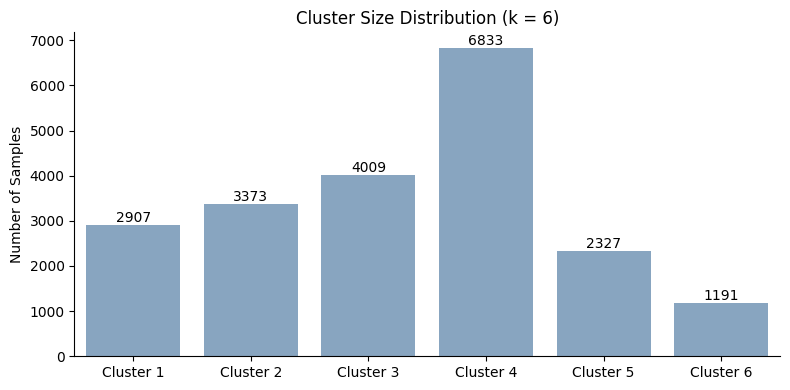

In [15]:
plot_cluster_size_distribution(fgc, fgc.best_k)

The variance-based pruning strategy produces the best overall clustering structure among the evaluated pruning approaches. The optimizer selects k = 6, achieving both the lowest clustering score and very strong stability, with consistently high cluster-wise Jaccard values across all clusters.

Compared to the previous pruning strategies, the resulting cluster sizes are substantially more balanced, indicating that variance-based pruning successfully reduces proximity sparsity while still preserving meaningful fine-grained structure in the regression forest. Importantly, no single cluster dominates the dataset, suggesting that the adaptive pruning criterion allows the forest to retain informative local substructure without collapsing excessively large regions together.

Overall, these results highlight the main advantage of variance-based pruning: because the pruning criterion adapts directly to the learned target structure of the Random Forest, it can preserve deep and informative branches where variance reduction remains meaningful while simultaneously coarsening regions where further splitting adds little additional information.